# Ablation study — Section 5.6

Four figures:

| Figure | Content |
|---|---|
| **1** `fig1_landing` | landing accuracy relative to the baseline (per-cell difference maps), degradation vs jump distance, stratified mean |
| **2** `fig2_bounce` | bounce at touchdown relative to the baseline (difference maps), stratified mean |
| **3** `fig3_liftoff` | lift-off state tracking as error / baseline error, plus a difference map per component (position, linear velocity, orientation, angular velocity) |
| **4** `fig4_landing_per_target` | landing error per target on the grid with the failed targets marked, paired with the difference maps of Figure 1 |

Targets are sampled randomly and independently per run, so nothing can be paired sample by sample.
Everything is compared over a shared grid partition of the command space: cell by cell, with
aggregates stratified over cells (each region weighted equally), cluster-bootstrap confidence
intervals over cells, and Wilcoxon signed-rank over cells with Holm correction.

## 1. Setup

In [14]:
import os
import os.path as osp
import warnings
from itertools import product

import numpy as np
import pandas as pd
import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 200)
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 500, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.30, "axes.axisbelow": True,
    "legend.frameon": False,
})

robot = "go1"
cwd = os.getcwd()
data_path = osp.abspath(osp.join(cwd, f"../../../../logs/rsl_rl/unitree_{robot}_jump/ablation"))
# data_path = "/absolute/path/to/ablation"      # <-- override if the relative path is wrong
print("data path :", data_path, "| exists:", osp.isdir(data_path))

FIG_DIR = osp.join(data_path, "figures_ablation")
os.makedirs(FIG_DIR, exist_ok=True)

BASELINE = "baseline"
EXPERIMENTS = {
    "baseline":                    "Baseline",
    "no_uarm":                     "w/o UARM",
    "no_liftoof_disc_penalty":     "w/o LO",
    "no_bounce_angular_touchdown": "w/o TD",
}
COLORS = {
    "baseline":                    "#2c3e50",
    "no_uarm":                     "#c0392b",
    "no_liftoof_disc_penalty":     "#2980b9",
    "no_bounce_angular_touchdown": "#e67e22",
}
LO_MAP_POLICY = "no_liftoof_disc_penalty"     # policy shown in the Figure 3 maps

PEN_CAP  = 0.50      # [m] failed jumps are censored here so accuracy is not selection-biased
GRID_NX, GRID_NY = 12, 8      # ~40 samples per run per cell with 4096 jumps
MIN_PER_CELL = 20             # do NOT lower this: thin cells make every per-cell estimate noise
D_KNEE   = 0.60      # [m] accuracy threshold identified in Section 5.3.1
INCLUDE_SEED_CAVEAT = False   # single-seed limitation sentence in the auto-generated draft
RATIO_MIN_DIST = 0.20  # [m] ignore near-zero commands when forming achieved/commanded ratios
SAVE_FIGS = True


def savefig(fig, name):
    if SAVE_FIGS:
        for ext in ("pdf", "png"):
            fig.savefig(osp.join(FIG_DIR, f"{name}.{ext}"), bbox_inches="tight")

data path : /home/riccardo/Documents/guided-rl-jump/logs/rsl_rl/unitree_go1_jump/ablation | exists: True


## 2. Loading

Two things that affect the numbers rather than just the plots:

* **Landing error is censored at `PEN_CAP` for failed jumps.** Averaging only over successful jumps
  is selection-biased: a policy that fails on the hard targets looks accurate on the ones that
  survive.
* **Bounce sentinel.** Section 4.3 sets the bounce cost to a high default when no valid touchdown is
  detected. If that value is present in `bounce_err.bin` it is a failure flag, not a distance, and it
  would inflate the bounce mean. The loader detects it and reports those samples as invalid
  touchdowns instead.

In [15]:
def _np(x):
    return np.asarray(x.detach().cpu().numpy() if hasattr(x, "detach") else x)


def _load(path):
    if not osp.isfile(path):
        return None
    o = joblib.load(path)
    return [_np(a) for a in o] if isinstance(o, (list, tuple)) else _np(o)


def _as_error(raw):
    # accepts an error array, or a [desired, actual] pair
    if raw is None:
        return None
    if (isinstance(raw, (list, tuple)) and len(raw) == 2
            and np.shape(raw[0]) == np.shape(raw[1]) and np.ndim(raw[0]) == 2):
        return np.asarray(raw[1], float) - np.asarray(raw[0], float)
    return np.asarray(raw, float)


def _mag(err, deg=False):
    if err is None:
        return None
    e = np.asarray(err, float)
    if e.ndim == 0:
        return None
    m = np.abs(e) if e.ndim == 1 else np.linalg.norm(e.reshape(len(e), -1), axis=1)
    return np.degrees(m) if deg else m


def detect_sentinel(v, frac=0.01):
    # a single value repeated in more than `frac` of samples and sitting in the upper tail
    if v is None or len(v) == 0:
        return None
    vals, counts = np.unique(np.round(np.asarray(v, float), 6), return_counts=True)
    hi = np.percentile(v, 75)
    cand = [(c, x) for x, c in zip(vals, counts) if c > frac * len(v) and x >= hi]
    return max(cand)[1] if cand else None


class DataExp:
    FILES = {"pos": "pos_err.bin", "fail": "failed.bin", "bounce": "bounce_err.bin",
             "lo_pos": "lo_pos_err.bin", "lo_vel": "lo_vel_err.bin",
             "lo_orient": "lo_orient_err.bin", "lo_ang_vel": "lo_ang_vel_err.bin"}

    def __init__(self, data_path, name):
        self.name = name
        self.exp_path = osp.join(data_path, name)
        self.label = EXPERIMENTS.get(name, name)
        self.color = COLORS.get(name, "#555")

    def load(self):
        self.raw = {k: _load(osp.join(self.exp_path, f)) for k, f in self.FILES.items()}
        return self

    def shapes(self):
        rows = []
        for k, v in self.raw.items():
            rows.append((self.name, k, "MISSING" if v is None else
                         (" | ".join(str(np.shape(a)) for a in v) if isinstance(v, list)
                          else str(v.shape))))
        return pd.DataFrame(rows, columns=["exp", "field", "shape"])

    def process(self):
        des = np.asarray(self.raw["pos"][0], float)
        act = np.asarray(self.raw["pos"][1], float)
        self.n = len(des)
        self.des_pos, self.actual_pos = des[:, :2], act[:, :2]

        self.pos_err = np.linalg.norm(self.des_pos - self.actual_pos, axis=1)
        f = self.raw["fail"]
        self.fail = np.zeros(self.n, bool) if f is None else np.asarray(f).reshape(-1).astype(bool)
        self.ok = ~self.fail
        self.pos_err_pen = np.where(self.fail, PEN_CAP, np.minimum(self.pos_err, PEN_CAP))

        self.bounce = _mag(_as_error(self.raw["bounce"]))
        self.bounce_sentinel = detect_sentinel(self.bounce) if self.bounce is not None else None
        self.bounce_valid = (np.ones(self.n, bool) if self.bounce is None
                             or self.bounce_sentinel is None
                             else ~np.isclose(self.bounce, self.bounce_sentinel))
        self.invalid_td = ~self.bounce_valid

        self.lo_pos     = _mag(_as_error(self.raw["lo_pos"]))
        self.lo_vel     = _mag(_as_error(self.raw["lo_vel"]))
        self.lo_orient  = _mag(_as_error(self.raw["lo_orient"]), deg=True)
        self.lo_ang_vel = _mag(_as_error(self.raw["lo_ang_vel"]))

        self.des_dist = np.linalg.norm(self.des_pos, axis=1)
        self.actual_dist = np.linalg.norm(self.actual_pos, axis=1)
        self.dist_ratio = np.where(self.des_dist >= RATIO_MIN_DIST,
                                   self.actual_dist / np.maximum(self.des_dist, 1e-6), np.nan)
        return self


# attr -> (pretty name, unit, restrict to successful jumps?)
METRICS = {
    "pos_err_pen": ("Landing error",              "m",     False),
    "fail":        ("Failure rate",               "%",     False),
    "dist_ratio":  ("Achieved / commanded dist.",  "-",     True),
    "bounce":      ("Bounce distance",            "m",     True),
    "lo_pos":      ("Lift-off position",          "m",     True),
    "lo_vel":      ("Lift-off linear velocity",   "m/s",   True),
    "lo_orient":   ("Lift-off orientation",       "deg",   True),
    "lo_ang_vel":  ("Lift-off angular velocity",  "rad/s", True),
}
LO_ATTRS = ["lo_pos", "lo_vel", "lo_orient", "lo_ang_vel"]
PCT = {"fail"}
MNAME = {k: v[0] for k, v in METRICS.items()}
MUNIT = {k: v[1] for k, v in METRICS.items()}

In [16]:
exps = {}
for name in EXPERIMENTS:
    e = DataExp(data_path, name)
    if not osp.isdir(e.exp_path):
        print(f"[skip] not found: {e.exp_path}")
        continue
    exps[name] = e.load().process()

base = exps[BASELINE]
abl = [n for n in EXPERIMENTS if n != BASELINE and n in exps]
LABELS = [e.label for e in exps.values()]
CLR = [e.color for e in exps.values()]

print("loaded:", {e.label: e.n for e in exps.values()})
print("failures:", {e.label: f"{int(e.fail.sum())} ({100*e.fail.mean():.2f}%)"
                    for e in exps.values()})

found = [e.label for e in exps.values() if e.bounce_sentinel is not None]
print("\nbounce sentinel found in:", found if found else "none "
      "(no invalid-touchdown default value present; that case is presumably in failed.bin)")
if base.bounce is not None:
    b, l = np.nanmean(base.bounce[base.ok]), np.nanmean(base.pos_err[base.ok])
    print(f"baseline mean bounce {b:.4f} m vs baseline mean landing error {l:.4f} m")
    print("  (bounce is the touchdown->rest displacement; it exceeding the landing error means")
    print("   the policy aims the touchdown point to absorb it, cf. Section 2.3)")

pd.concat([e.shapes() for e in exps.values()], ignore_index=True) \
  .pivot(index="field", columns="exp", values="shape")

loaded: {'Baseline': 4096, 'w/o UARM': 4096, 'w/o LO': 4096, 'w/o TD': 4096}
failures: {'Baseline': '62 (1.51%)', 'w/o UARM': '114 (2.78%)', 'w/o LO': '0 (0.00%)', 'w/o TD': '170 (4.15%)'}

bounce sentinel found in: none (no invalid-touchdown default value present; that case is presumably in failed.bin)
baseline mean bounce 0.1561 m vs baseline mean landing error 0.0726 m
  (bounce is the touchdown->rest displacement; it exceeding the landing error means
   the policy aims the touchdown point to absorb it, cf. Section 2.3)


exp,baseline,no_bounce_angular_touchdown,no_liftoof_disc_penalty,no_uarm
field,,,,
bounce,"(4096,)","(4096,)","(4096,)","(4096,)"
fail,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_ang_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_orient,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_pos,"(4096,)","(4096,)","(4096,)","(4096,)"
lo_vel,"(4096,)","(4096,)","(4096,)","(4096,)"
pos,"(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)","(2, 4096, 3)"


## 3. Grid partition, stratified means and paired tests

In [17]:
class Grid:
    def __init__(self, xy, nx, ny):
        self.xe = np.linspace(xy[:, 0].min(), xy[:, 0].max() + 1e-9, nx + 1)
        self.ye = np.linspace(xy[:, 1].min(), xy[:, 1].max() + 1e-9, ny + 1)
        self.nx, self.ny, self.n_cells = nx, ny, nx * ny
        cx = 0.5 * (self.xe[:-1] + self.xe[1:])
        cy = 0.5 * (self.ye[:-1] + self.ye[1:])
        self.centroids = np.array([[cx[i], cy[j]] for i, j in product(range(nx), range(ny))])

    def assign(self, xy):
        ix = np.clip(np.digitize(xy[:, 0], self.xe) - 1, 0, self.nx - 1)
        iy = np.clip(np.digitize(xy[:, 1], self.ye) - 1, 0, self.ny - 1)
        return (ix * self.ny + iy).astype(int)

    def plot(self, ax, values, **kw):
        g = np.full((self.nx, self.ny), np.nan)
        for c in range(self.n_cells):
            g[c // self.ny, c % self.ny] = values[c]
        return ax.pcolormesh(self.xe, self.ye, g.T, shading="flat", **kw)


part = Grid(np.vstack([e.des_pos for e in exps.values()]), GRID_NX, GRID_NY)
for e in exps.values():
    e.cell = part.assign(e.des_pos)

counts = pd.DataFrame({e.label: np.bincount(e.cell, minlength=part.n_cells) for e in exps.values()})
VALID = (counts >= MIN_PER_CELL).all(axis=1).values
valid_cells = np.nonzero(VALID)[0]
cdist = np.linalg.norm(part.centroids, axis=1)
XLIM = (part.xe[0] - 0.03, part.xe[-1] + 0.03)
YLIM = (part.ye[0] - 0.03, part.ye[-1] + 0.03)

print(f"grid {GRID_NX}x{GRID_NY} | usable cells {VALID.sum()}/{part.n_cells} | "
      f"samples per cell: min {counts.values.min()}, median {int(np.median(counts.values))}")


def cell_values(e, attr):
    v = getattr(e, attr, None)
    if v is None:
        return np.full(part.n_cells, np.nan)
    v = np.asarray(v, float)
    restrict = METRICS[attr][2]
    extra = e.bounce_valid if attr == "bounce" else np.ones(e.n, bool)
    out = np.full(part.n_cells, np.nan)
    for c in range(part.n_cells):
        m = (e.cell == c) & extra
        if restrict:
            m = m & e.ok
        if m.sum() >= 3:
            out[c] = np.nanmean(v[m])
    return 100.0 * out if attr in PCT else out


CELL = {a: pd.DataFrame({n: cell_values(e, a) for n, e in exps.items()}) for a in METRICS}


def strat(attr, policy):
    return float(np.nanmean(CELL[attr].loc[valid_cells, policy]))


def cluster_ci(d, n_boot=5000, seed=0):
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    if len(d) < 3:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    s = np.nanmean(d[rng.integers(0, len(d), (n_boot, len(d)))], axis=1)
    return float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))


def stars(p):
    return "***" if p < 1e-3 else "**" if p < 1e-2 else "*" if p < 5e-2 else "n.s."


def holm(p):
    p = np.asarray(p, float)
    m, adj, run = len(p), np.empty(len(p)), 0.0
    for rank, i in enumerate(np.argsort(p)):
        run = max(run, (m - rank) * p[i])
        adj[i] = min(run, 1.0)
    return adj


rows = []
for n in abl:
    for a in METRICS:
        x = CELL[a].loc[valid_cells, BASELINE].values
        y = CELL[a].loc[valid_cells, n].values
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 5:
            continue
        x, y = x[m], y[m]
        d = y - x
        lo, hi = cluster_ci(d)
        try:
            p = stats.wilcoxon(x, y).pvalue if np.any(d != 0) else 1.0
        except ValueError:
            p = 1.0
        rows.append(dict(Ablation=exps[n].label, attr=a, Metric=f"{MNAME[a]} [{MUNIT[a]}]",
                         cells=int(m.sum()), baseline=x.mean(), ablation=y.mean(),
                         diff=d.mean(), ci_lo=lo, ci_hi=hi,
                         rel=100 * d.mean() / abs(x.mean()) if x.mean() else np.nan,
                         worse=100 * np.mean(d > 0), p=p))
stats_df = pd.DataFrame(rows)
stats_df["p_holm"] = holm(stats_df["p"].values)
stats_df["sig"] = [stars(p) for p in stats_df["p_holm"]]

# Wilcoxon is a rank test: it asks whether the TYPICAL cell is worse. A spatially concentrated
# effect can move the mean a long way while leaving the median near zero, so it is also recorded
# whether the cluster-bootstrap CI on the MEAN difference excludes zero. The two disagreeing is
# informative, not contradictory: "regional" means a minority of the workspace is badly affected.
stats_df["ci_excl0"] = (stats_df["ci_lo"] > 0) | (stats_df["ci_hi"] < 0)
stats_df["verdict"] = np.where(stats_df["p_holm"] < 0.05, "uniform",
                      np.where(stats_df["ci_excl0"], "regional", "no effect"))
stats_df["mark"] = np.where(stats_df["p_holm"] < 0.05, stats_df["sig"],
                   np.where(stats_df["ci_excl0"], "reg.", "n.s."))


def S(n, a, f):
    r = stats_df[(stats_df["Ablation"] == exps[n].label) & (stats_df["attr"] == a)]
    return np.nan if r.empty else r.iloc[0][f]


# --- failures are compared on RAW COUNTS, not cell-wise.
# Every failure sits in the same small cluster at the reachability limit, so almost every cell
# holds a zero-vs-zero difference and the cell-level Wilcoxon has essentially no power. Fisher's
# exact test on the counts is the right instrument; the interval is the Jeffreys interval, with
# the standard boundary convention so that a zero-failure policy gets a one-sided upper bound.
def failure_stats():
    bk, bn = int(base.fail.sum()), base.n
    rows = []
    for n, e in exps.items():
        k, nn = int(e.fail.sum()), e.n
        lo, hi = stats.beta.ppf([0.025, 0.975], k + 0.5, nn - k + 0.5)
        if k == 0:
            lo = 0.0
        if k == nn:
            hi = 1.0
        r = dict(Policy=e.label, failures=k, n=nn, rate=100 * k / nn,
                 ci_lo=100 * lo, ci_hi=100 * hi, odds=np.nan, p=np.nan)
        if n != BASELINE:
            odds, pv = stats.fisher_exact([[k, nn - k], [bk, bn - bk]])
            r["odds"], r["p"] = odds, pv
        rows.append(r)
    df = pd.DataFrame(rows)
    m = df["p"].notna().values
    df["p_holm"] = np.nan
    df.loc[m, "p_holm"] = holm(df.loc[m, "p"].values)
    df["sig"] = [stars(x) if np.isfinite(x) else "" for x in df["p_holm"]]
    return df


FAIL_DF = failure_stats()
print("Failure rate — Fisher exact on raw counts, Holm-corrected, Jeffreys 95% CI")
display(FAIL_DF.round(4))
for _, r in FAIL_DF.iterrows():
    if r["failures"] == 0:
        print(f"  {r['Policy']}: no failures in {int(r['n'])} jumps -> quote as "
              f"'<{r['ci_hi']:.3f}% (95% upper bound)', not '0%'")

summary = pd.DataFrame([{"Policy": e.label,
                         **{f"{MNAME[a]} [{MUNIT[a]}]": strat(a, n) for a in METRICS}}
                        for n, e in exps.items()])
display(summary.set_index("Policy").T.round(4))

# --- specificity matrix: relative change per (metric, ablation). The three-way dissociation
#     between the reward terms should be readable straight off this table.
rel = stats_df.pivot(index="attr", columns="Ablation", values="rel")
sg = stats_df.pivot(index="attr", columns="Ablation", values="mark")
order = [a for a in METRICS if a in rel.index]
diss = (rel.loc[order].round(0).astype("Int64").astype(str) + " % " + sg.loc[order])
diss.index = [MNAME[a] for a in order]
diss = diss[[exps[n].label for n in abl]]

# the failure row comes from Fisher on raw counts, not from the cell-level test
if MNAME["fail"] in diss.index:
    bk = int(base.fail.sum())
    for n in abl:
        r = FAIL_DF[FAIL_DF["Policy"] == exps[n].label].iloc[0]
        chg = 100 * (r["failures"] - bk) / bk if bk else np.nan
        diss.loc[MNAME["fail"], exps[n].label] = (
            f"{int(r['failures'])} vs {bk} ({chg:+.0f} %) {r['sig']}")

print("Change vs baseline. Stars = Holm-corrected Wilcoxon over cells;")
print("'reg.' = the mean difference excludes zero but the typical cell does not move,")
print("i.e. a minority of the workspace is strongly affected. Failures: Fisher exact on counts.")
diss

grid 12x8 | usable cells 96/96 | samples per cell: min 24, median 43
Failure rate — Fisher exact on raw counts, Holm-corrected, Jeffreys 95% CI


/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")
/home/riccardo/Documents/guided-rl-jump/_isaac_sim/kit/python/lib/python3.10/site-packages/scipy/stats/_morestats.py:3428: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,Policy,failures,n,rate,ci_lo,ci_hi,odds,p,p_holm,sig
0,Baseline,62,4096,1.5137,1.1732,1.9226,NaN,NaN,NaN,
1,w/o UARM,114,4096,2.7832,2.3123,3.3208,1.8627,0.0001,0.0001,***
2,w/o LO,0,4096,0.0000,0.0000,0.0613,0.0000,0.0000,0.0000,***
3,w/o TD,170,4096,4.1504,3.5716,4.7939,2.8174,0.0000,0.0000,***


  w/o LO: no failures in 4096 jumps -> quote as '<0.061% (95% upper bound)', not '0%'


Policy,Baseline,w/o UARM,w/o LO,w/o TD
Landing error [m],0.0800,0.0889,0.1015,0.0876
Failure rate [%],1.6704,2.8504,0.0000,4.3497
Achieved / commanded dist. [-],0.9300,0.9205,0.9006,0.9449
Bounce distance [m],0.1594,0.1584,0.1422,0.1683
Lift-off position [m],0.0211,0.0169,0.0262,0.0214
Lift-off linear velocity [m/s],0.1988,0.2813,0.4999,0.2387
Lift-off orientation [deg],2.2986,2.1502,3.0759,2.7174
Lift-off angular velocity [rad/s],0.4308,0.4666,1.3814,0.5812


Change vs baseline. Stars = Holm-corrected Wilcoxon over cells;
'reg.' = the mean difference excludes zero but the typical cell does not move,
i.e. a minority of the workspace is strongly affected. Failures: Fisher exact on counts.


Ablation,w/o UARM,w/o LO,w/o TD
Landing error,11 % **,27 % ***,10 % n.s.
Failure rate,114 vs 62 (+84 %) ***,0 vs 62 (-100 %) ***,170 vs 62 (+174 %) ***
Achieved / commanded dist.,-1 % *,-3 % **,1 % ***
Bounce distance,1 % n.s.,-11 % reg.,9 % ***
Lift-off position,-19 % ***,25 % ***,4 % n.s.
Lift-off linear velocity,42 % ***,152 % reg.,21 % ***
Lift-off orientation,-6 % reg.,34 % ***,18 % ***
Lift-off angular velocity,8 % n.s.,221 % ***,34 % ***


In [18]:
# shared plotting helpers used by all four figures
def shared_norm(attr, pct=97, floor=1e-4):
    d = np.concatenate([(CELL[attr][n].values - CELL[attr][BASELINE].values)[valid_cells]
                        for n in abl])
    lim = np.nanpercentile(np.abs(d), pct)
    lim = floor if (not np.isfinite(lim) or lim <= 0) else lim
    return TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)


def delta_map(ax, attr, policy, norm, title=True, cmap="coolwarm"):
    d = np.where(VALID, CELL[attr][policy].values - CELL[attr][BASELINE].values, np.nan)
    m = part.plot(ax, d, cmap=cmap, norm=norm)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_xlabel("Target $x$ [m]")
    if title:
        ax.set_title(f"{exps[policy].label} $-$ Baseline\n"
                     f"$\\Delta$ {np.nanmean(d[valid_cells]):+.3f} {MUNIT[attr]} | worse in "
                     f"{100*np.nanmean(d[valid_cells] > 0):.0f}% of workspace", fontsize=9.5)
    return m


def bar_with_ci(ax, attr, fmt="{:.3f}"):
    mu, elo, ehi = [], [], []
    for n in exps:
        v = CELL[attr].loc[valid_cells, n].values
        m = np.nanmean(v)
        lo, hi = cluster_ci(v)
        mu.append(m); elo.append(max(m - lo, 0)); ehi.append(max(hi - m, 0))
    ax.bar(LABELS, mu, yerr=[elo, ehi], color=CLR, alpha=0.88, capsize=5)
    span = max(np.nanmax(np.array(mu) + np.array(ehi)), 1e-9)
    for i, (v, h) in enumerate(zip(mu, ehi)):
        ax.text(i, v + h + 0.03 * span, fmt.format(v), ha="center", va="bottom", fontsize=8)
    ax.set_ylim(0, 1.14 * span)
    ax.tick_params(axis="x", rotation=15, labelsize=9)


def bar_paired_diff(ax, attr):
    # the statistically correct comparison: the paired per-cell difference and its CI.
    # The absolute-mean CIs carry the between-cell variance of the workspace, which is far
    # larger than the between-policy difference, so those bars can overlap while the paired
    # difference is unambiguous.
    labs, mu, elo, ehi, cols = [], [], [], [], []
    for n in abl:
        d = (CELL[attr][n].values - CELL[attr][BASELINE].values)[valid_cells]
        d = d[np.isfinite(d)]
        m = d.mean()
        lo, hi = cluster_ci(d)
        labs.append(exps[n].label); mu.append(m)
        elo.append(max(m - lo, 0)); ehi.append(max(hi - m, 0)); cols.append(exps[n].color)
    ax.bar(labs, mu, yerr=[elo, ehi], color=cols, alpha=0.88, capsize=5)
    ax.axhline(0, color="black", lw=1)
    span = max(np.nanmax(np.abs(np.array(mu)) + np.array(ehi)), 1e-9)
    for i, n in enumerate(abl):
        up = mu[i] >= 0
        ax.text(i, mu[i] + (ehi[i] + 0.05 * span) * (1 if up else -1),
                f"{mu[i]:+.3f} {S(n, attr, 'sig')}", ha="center",
                va="bottom" if up else "top", fontsize=8)
    lo_y = min(0, np.nanmin(np.array(mu) - np.array(elo))) - 0.25 * span
    hi_y = max(0, np.nanmax(np.array(mu) + np.array(ehi))) + 0.25 * span
    ax.set_ylim(lo_y, hi_y)
    ax.tick_params(axis="x", rotation=15, labelsize=9)


R_EDGES = np.quantile(cdist[valid_cells], np.linspace(0, 1, 7))
R_C = 0.5 * (R_EDGES[:-1] + R_EDGES[1:])


def plot_radial_delta(ax, attr):
    for n in abl:
        v = CELL[attr][n].values - CELL[attr][BASELINE].values
        y, lo, hi = [], [], []
        for a, b in zip(R_EDGES[:-1], R_EDGES[1:]):
            sel = valid_cells[(cdist[valid_cells] >= a) & (cdist[valid_cells] <= b)]
            y.append(np.nanmean(v[sel]))
            l, h = cluster_ci(v[sel], n_boot=2000)
            lo.append(l); hi.append(h)
        ax.plot(R_C, y, "-o", ms=4, lw=2, color=exps[n].color,
                label=f"{exps[n].label} $-$ Baseline")
        ax.fill_between(R_C, lo, hi, color=exps[n].color, alpha=0.15, lw=0)
    ax.axhline(0, color="black", lw=1)
    ax.axvline(D_KNEE, color="grey", ls="--", lw=1.2)
    ax.annotate(f"{D_KNEE} m", xy=(D_KNEE, ax.get_ylim()[0]), xytext=(3, 4),
                textcoords="offset points", fontsize=8, color="grey", va="bottom")
    ax.set_xlabel("Commanded distance [m]")
    ax.legend(fontsize=8)

### 3.1 Is the degradation confined to long jumps?

Section 5.3.1 already identifies ~0.6 m as the distance beyond which the baseline itself becomes
conservative. The ablation gap is therefore expected to be a **threshold** effect, not a monotone
trend, so it is tested as one: a two-sided Mann-Whitney over cells comparing the per-cell gap
inside and outside `D_KNEE`. A rank correlation over cells looks for a monotone trend and will
report nothing even when the threshold effect is obvious.

In [19]:
# --- is the degradation confined to long jumps?
# Two-sided Mann-Whitney over cells comparing the per-cell gap in the near regime (d <= D_KNEE)
# against the far regime (d > D_KNEE). This tests the threshold behaviour reported in Section
# 5.3.1 rather than a monotone trend, which a rank correlation would look for and miss.
def knee_test(n, attr="pos_err_pen"):
    d = CELL[attr][n].values - CELL[attr][BASELINE].values
    near = d[valid_cells[cdist[valid_cells] <= D_KNEE]]
    far = d[valid_cells[cdist[valid_cells] > D_KNEE]]
    near, far = near[np.isfinite(near)], far[np.isfinite(far)]
    if len(near) < 5 or len(far) < 5:
        return None
    u = stats.mannwhitneyu(far, near, alternative="two-sided")
    lo_n, hi_n = cluster_ci(near)
    lo_f, hi_f = cluster_ci(far)
    return dict(Ablation=exps[n].label, cells_near=len(near), cells_far=len(far),
                near=near.mean(), near_lo=lo_n, near_hi=hi_n,
                far=far.mean(), far_lo=lo_f, far_hi=hi_f,
                ratio=far.mean() / near.mean() if near.mean() else np.nan, p=u.pvalue)


knee = pd.DataFrame([r for n in abl if (r := knee_test(n)) is not None])
if len(knee):
    knee["p_holm"] = holm(knee["p"].values)
    knee["sig"] = [stars(p) for p in knee["p_holm"]]
print(f"Per-cell landing-error gap, near (d <= {D_KNEE} m) vs far (d > {D_KNEE} m)")
knee.round(4)

Per-cell landing-error gap, near (d <= 0.6 m) vs far (d > 0.6 m)


,Ablation,cells_near,cells_far,near,near_lo,near_hi,far,far_lo,far_hi,ratio,p,p_holm,sig
0,w/o UARM,52,44,0.0048,0.0031,0.0068,0.0137,0.0029,0.0250,2.8462,0.5058,1.0000,n.s.
1,w/o LO,52,44,0.0043,0.0014,0.0074,0.0419,0.0269,0.0576,9.6721,0.0001,0.0004,***
2,w/o TD,52,44,-0.0014,-0.0036,0.0008,0.0182,0.0010,0.0385,-13.3596,0.6458,1.0000,n.s.


## 4. Figure 1 — landing accuracy relative to the baseline

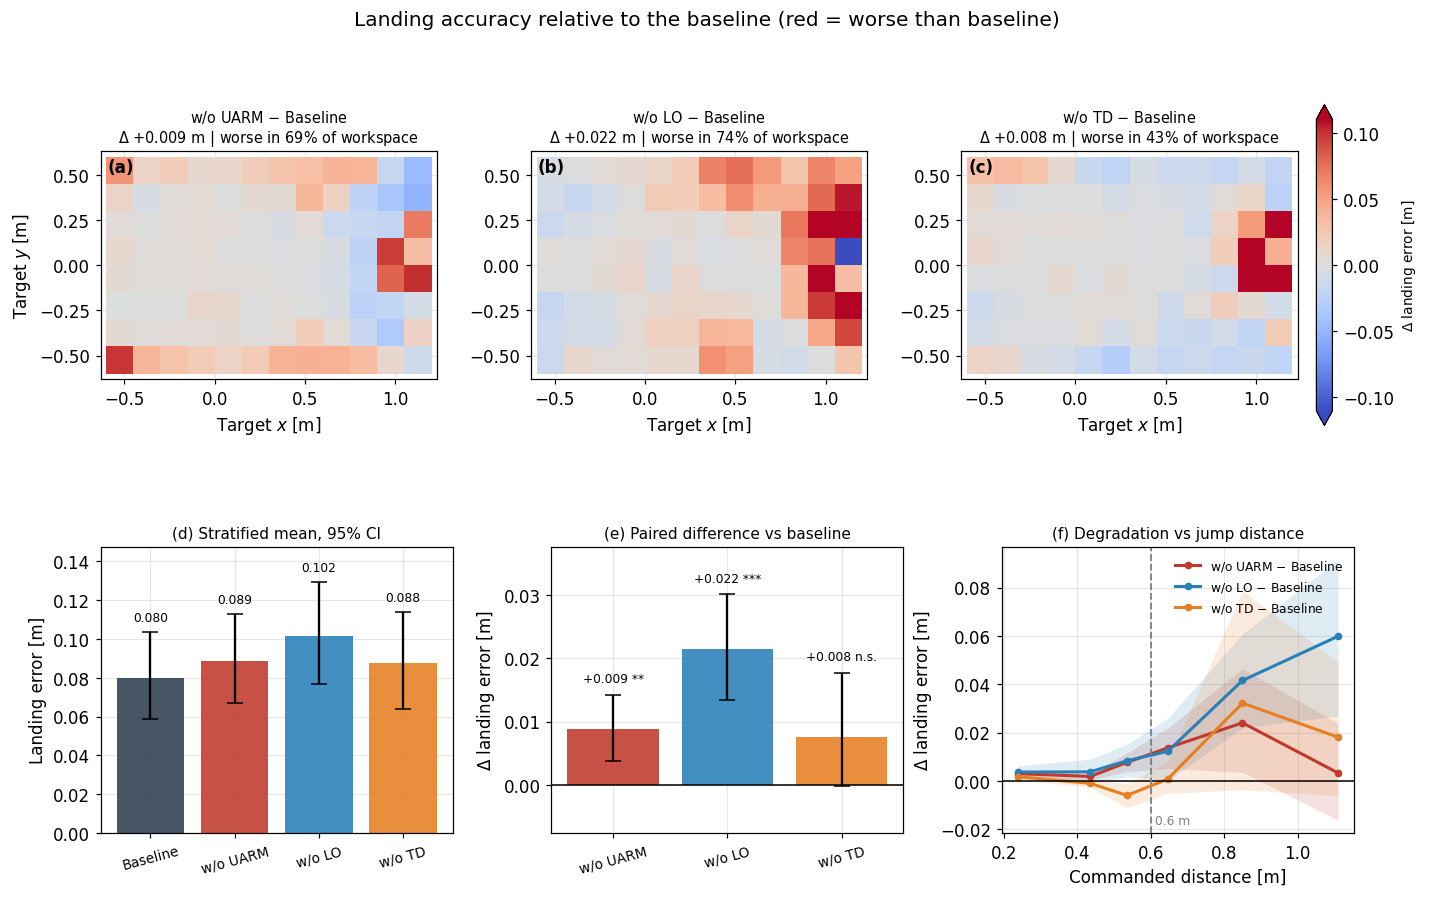

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
0,w/o UARM,0.08,0.0889,0.0089,0.0038,0.0143,11.1167,68.7500,0.0048,**
8,w/o LO,0.08,0.1015,0.0215,0.0134,0.0301,26.9420,73.9583,0.0000,***
16,w/o TD,0.08,0.0876,0.0076,-0.0002,0.0177,9.5056,42.7083,0.6506,n.s.


In [20]:
attr = "pos_err_pen"
nA = len(abl)
fig = plt.figure(figsize=(4.9 * max(nA, 3), 8.6))
gs = fig.add_gridspec(2, max(nA, 3), height_ratios=[1.12, 1.0], hspace=0.40, wspace=0.28)
norm = shared_norm(attr)

top = []
for i, n in enumerate(abl):
    ax = fig.add_subplot(gs[0, i])
    top.append(ax)
    m = delta_map(ax, attr, n, norm)
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
    ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes, va="top",
            fontsize=11, fontweight="bold")
cb = fig.colorbar(m, ax=top, pad=0.015, extend="both", fraction=0.03)
cb.set_label("$\\Delta$ landing error [m]", fontsize=9)

ax = fig.add_subplot(gs[1, 0])
bar_with_ci(ax, attr)
ax.set_ylabel("Landing error [m]")
ax.set_title(f"({chr(97+nA)}) Stratified mean, 95% CI", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
bar_paired_diff(ax, attr)
ax.set_ylabel("$\\Delta$ landing error [m]")
ax.set_title(f"({chr(98+nA)}) Paired difference vs baseline", fontsize=10)

ax = fig.add_subplot(gs[1, 2])
plot_radial_delta(ax, attr)
ax.set_ylabel("$\\Delta$ landing error [m]")
ax.set_title(f"({chr(99+nA)}) Degradation vs jump distance", fontsize=10)

fig.suptitle("Landing accuracy relative to the baseline (red = worse than baseline)", y=0.98)
savefig(fig, "fig1_landing")
plt.show()

COLS = ["Ablation", "baseline", "ablation", "diff", "ci_lo", "ci_hi", "rel", "worse",
        "p_holm", "sig"]
stats_df[stats_df["attr"] == attr][COLS].round(4)

## 5. Figure 2 — bounce at touchdown relative to the baseline

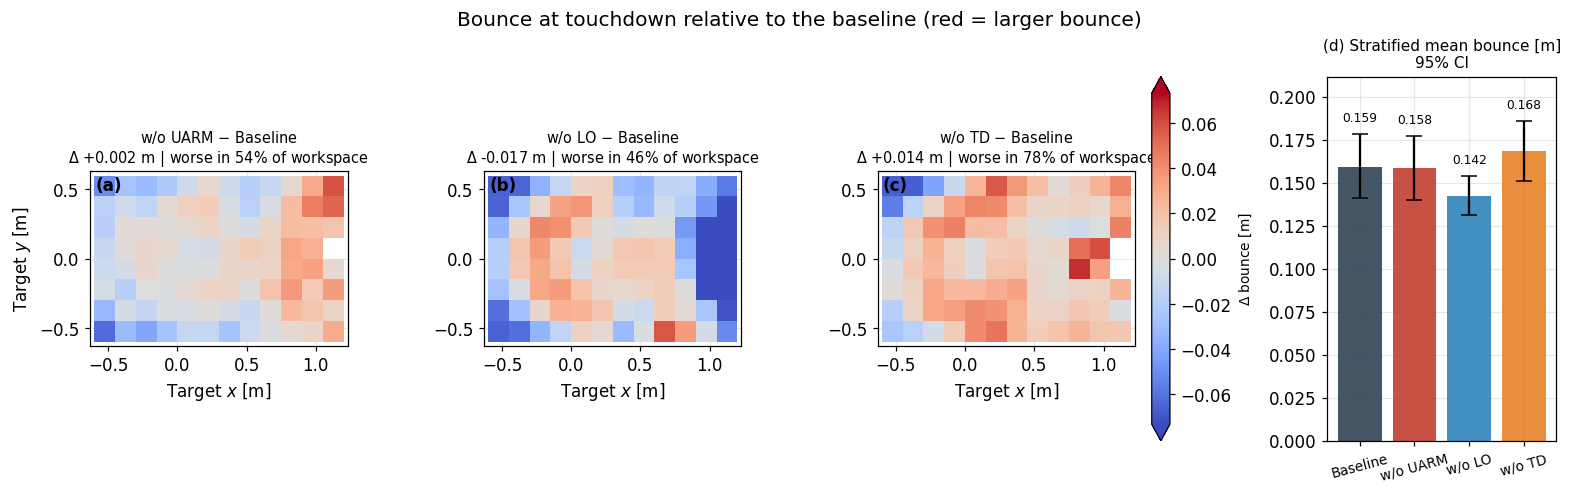

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
3,w/o UARM,0.1567,0.1584,0.0017,-0.0023,0.0058,1.1099,54.7368,0.6506,n.s.
11,w/o LO,0.1594,0.1422,-0.0171,-0.0267,-0.0083,-10.7435,45.8333,0.1172,n.s.
19,w/o TD,0.1541,0.1683,0.0142,0.0095,0.0188,9.2273,79.7872,0.0000,***


In [21]:
if base.bounce is None:
    print("bounce_err.bin not found — skipping Figure 2")
else:
    attr = "bounce"
    fig = plt.figure(figsize=(4.4 * nA + 4.0, 4.3))
    gs = fig.add_gridspec(1, nA + 1, width_ratios=[1] * nA + [0.85], wspace=0.55)
    norm = shared_norm(attr)

    top = []
    for i, n in enumerate(abl):
        ax = fig.add_subplot(gs[0, i])
        top.append(ax)
        m = delta_map(ax, attr, n, norm)
        if i == 0:
            ax.set_ylabel("Target $y$ [m]")
        ax.text(0.02, 0.97, f"({chr(97+i)})", transform=ax.transAxes, va="top",
                fontsize=11, fontweight="bold")
    cb = fig.colorbar(m, ax=top, pad=0.015, extend="both", fraction=0.03)
    cb.set_label("$\\Delta$ bounce [m]", fontsize=9)

    ax = fig.add_subplot(gs[0, nA])
    bar_with_ci(ax, attr)
    ax.set_title(f"({chr(97+nA)}) Stratified mean bounce [m]\n95% CI", fontsize=10)

    fig.suptitle("Bounce at touchdown relative to the baseline (red = larger bounce)", y=1.02)
    savefig(fig, "fig2_bounce")
    plt.show()

    display(stats_df[stats_df["attr"].isin(["bounce", "invalid_td"])][COLS].round(4))

## 6. Figure 3 — lift-off state tracking

Left: each lift-off error component divided by the baseline value, so 1.0 is the baseline and the
four components are comparable despite having different units. Right: the per-cell difference
against the baseline for each component, for the policy set in `LO_MAP_POLICY`.

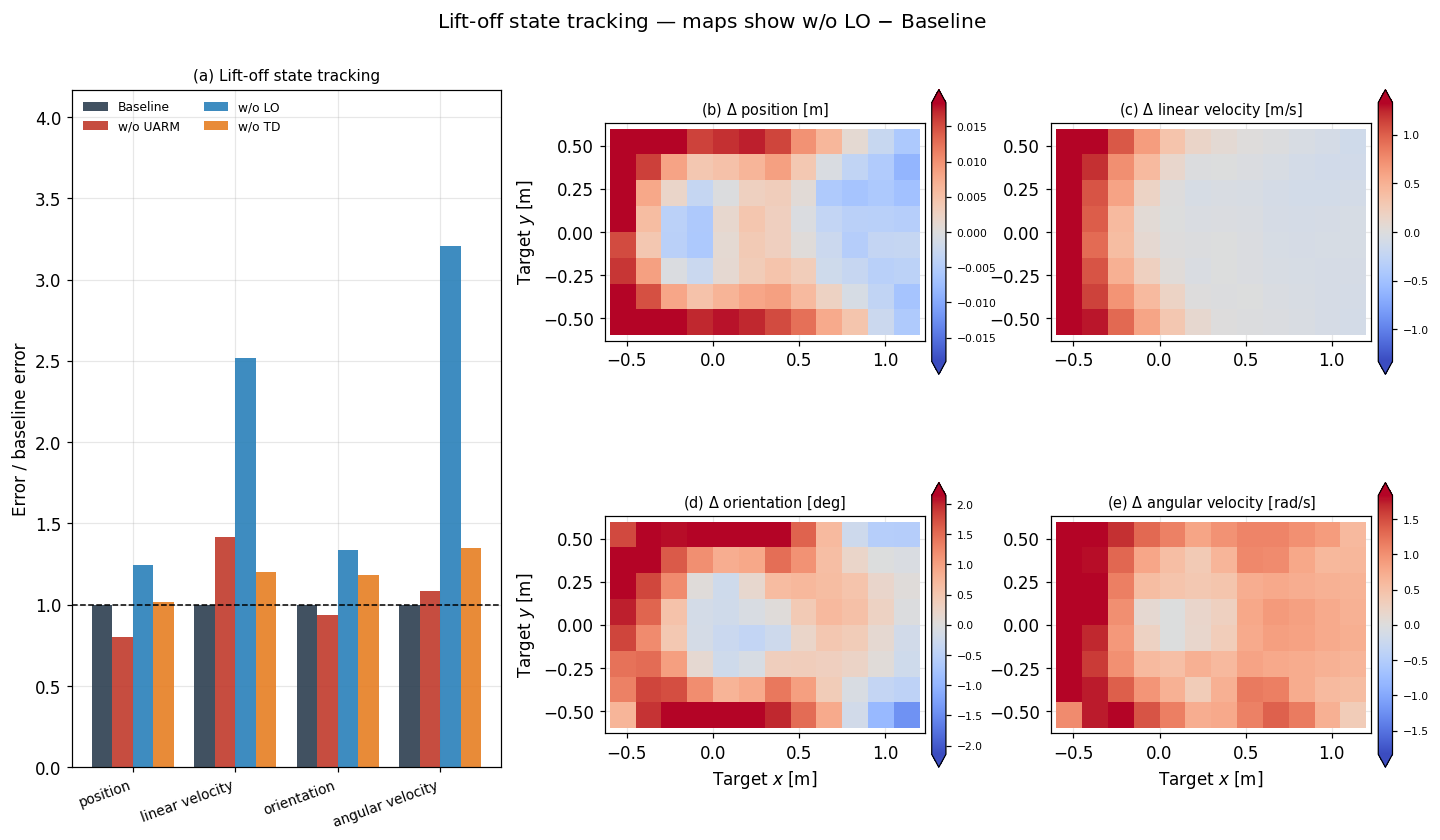

,Ablation,baseline,ablation,diff,ci_lo,ci_hi,rel,worse,p_holm,sig
4,w/o UARM,0.0208,0.0169,-0.0039,-0.0047,-0.0032,-18.8830,16.8421,0.0000,***
5,w/o UARM,0.1978,0.2813,0.0836,0.0598,0.1072,42.2617,62.1053,0.0000,***
6,w/o UARM,2.2982,2.1502,-0.1480,-0.2679,-0.0369,-6.4391,47.3684,0.6218,n.s.
7,w/o UARM,0.4313,0.4666,0.0353,-0.0021,0.0727,8.1840,56.8421,0.6218,n.s.
12,w/o LO,0.0211,0.0262,0.0052,0.0032,0.0072,24.5717,62.5000,0.0008,***
13,w/o LO,0.1988,0.4999,0.3011,0.1895,0.4155,151.5084,46.8750,0.1232,n.s.
14,w/o LO,2.2986,3.0759,0.7773,0.5848,0.9645,33.8139,75.0000,0.0000,***
15,w/o LO,0.4308,1.3814,0.9506,0.8478,1.0547,220.6799,97.9167,0.0000,***
20,w/o TD,0.0205,0.0214,0.0009,-0.0001,0.0018,4.1404,55.3191,0.6218,n.s.
21,w/o TD,0.1967,0.2387,0.0419,0.0308,0.0544,21.3192,88.2979,0.0000,***


In [22]:
lo_have = [a for a in LO_ATTRS if np.isfinite(CELL[a][BASELINE].values[valid_cells]).any()]
tgt = LO_MAP_POLICY if LO_MAP_POLICY in exps else abl[0]

if not lo_have:
    print("no lift-off files found — skipping Figure 3")
else:
    fig = plt.figure(figsize=(15.5, 8.0))
    gs = fig.add_gridspec(2, 3, width_ratios=[1.25, 1, 1], hspace=0.38, wspace=0.28)

    # (a) normalised components, all policies
    ax = fig.add_subplot(gs[:, 0])
    x = np.arange(len(lo_have))
    w = 0.8 / max(len(exps), 1)
    for i, (n, e) in enumerate(exps.items()):
        ax.bar(x + i * w - 0.4 + w / 2,
               [strat(a, n) / max(strat(a, BASELINE), 1e-12) for a in lo_have],
               width=w, color=e.color, alpha=0.9, label=e.label)
    ax.axhline(1.0, color="black", ls="--", lw=1)
    hi = max(strat(a, n) / max(strat(a, BASELINE), 1e-12) for a in lo_have for n in exps)
    ax.set_ylim(0, 1.30 * max(hi, 1.0))
    ax.set_xticks(x)
    ax.set_xticklabels([MNAME[a].replace("Lift-off ", "") for a in lo_have],
                       rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("Error / baseline error")
    ax.set_title("(a) Lift-off state tracking", fontsize=10)
    ax.legend(fontsize=8, loc="upper left", ncol=2)

    # (b)-(e) per-component difference maps for one policy, each with its own scale
    slots = [gs[0, 1], gs[0, 2], gs[1, 1], gs[1, 2]]
    for k, (a, slot) in enumerate(zip(lo_have, slots)):
        ax = fig.add_subplot(slot)
        m = delta_map(ax, a, tgt, shared_norm(a), title=False)
        ax.set_title(f"({chr(98+k)}) $\\Delta$ {MNAME[a].replace('Lift-off ', '')} "
                     f"[{MUNIT[a]}]", fontsize=9.5)
        if k in (0, 2):
            ax.set_ylabel("Target $y$ [m]")
        if k in (0, 1):
            ax.set_xlabel("")
        cb = fig.colorbar(m, ax=ax, pad=0.02, extend="both", fraction=0.045)
        cb.ax.tick_params(labelsize=7)

    fig.suptitle(f"Lift-off state tracking — maps show {exps[tgt].label} $-$ Baseline", y=0.97)
    savefig(fig, "fig3_liftoff")
    plt.show()

    display(stats_df[stats_df["attr"].isin(lo_have)][COLS].round(4))

## 7. Figure 4 — landing error per target, with failures, next to the difference maps

Top row: mean landing error per grid cell for every policy, with the individual failed targets
overlaid as black crosses. Bottom row: the same difference maps as Figure 1, aligned under the
ablation they belong to, so the absolute performance and the change relative to the baseline can be
read off the same grid.

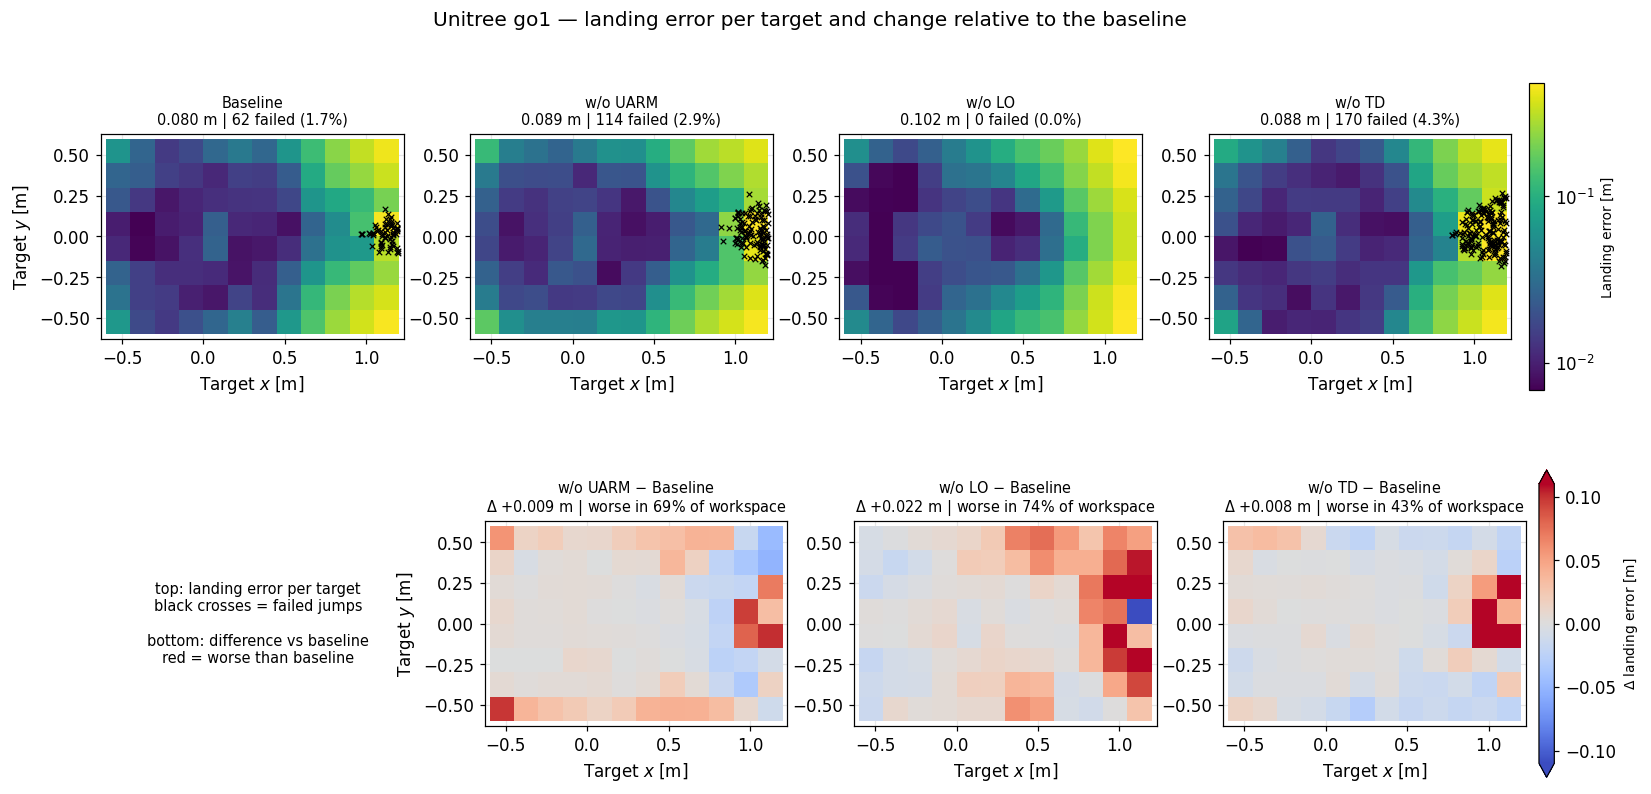

In [23]:
attr = "pos_err_pen"
ncol = len(exps)
fig = plt.figure(figsize=(4.3 * ncol, 8.2))
gs = fig.add_gridspec(2, ncol, height_ratios=[1.0, 1.0], hspace=0.26, wspace=0.22)

vals = np.concatenate([CELL[attr][n].values[valid_cells] for n in exps])
vmin = max(np.nanpercentile(vals, 2), 1e-3)
vmax = np.nanpercentile(vals, 99)
anorm = LogNorm(vmin=vmin, vmax=vmax)

row0 = []
for i, (n, e) in enumerate(exps.items()):
    ax = fig.add_subplot(gs[0, i])
    row0.append(ax)
    v = np.where(VALID, CELL[attr][n].values, np.nan)
    m0 = part.plot(ax, v, cmap="viridis", norm=anorm)
    ax.scatter(e.des_pos[e.fail, 0], e.des_pos[e.fail, 1], s=13, marker="x",
               color="black", lw=0.8, zorder=10)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM); ax.set_aspect("equal", "box")
    ax.set_title(f"{e.label}\n{strat(attr, n):.3f} m | {int(e.fail.sum())} failed "
                 f"({strat('fail', n):.1f}%)", fontsize=9.5)
    ax.set_xlabel("Target $x$ [m]")
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
cb = fig.colorbar(m0, ax=row0, pad=0.012, fraction=0.026)
cb.set_label("Landing error [m]", fontsize=9)
cb.ax.minorticks_off()

norm = shared_norm(attr)
row1 = []
for i, n in enumerate(abl):
    ax = fig.add_subplot(gs[1, i + 1])
    row1.append(ax)
    m1 = delta_map(ax, attr, n, norm)
    if i == 0:
        ax.set_ylabel("Target $y$ [m]")
cb = fig.colorbar(m1, ax=row1, pad=0.012, extend="both", fraction=0.026)
cb.set_label("$\\Delta$ landing error [m]", fontsize=9)

ax = fig.add_subplot(gs[1, 0])
ax.axis("off")
ax.text(0.5, 0.5, "top: landing error per target\nblack crosses = failed jumps\n\n"
                  "bottom: difference vs baseline\nred = worse than baseline",
        ha="center", va="center", fontsize=9.5, transform=ax.transAxes)

fig.suptitle(f"Unitree {robot} — landing error per target and change relative to the baseline",
             y=0.96)
savefig(fig, "fig4_landing_per_target")
plt.show()

## 8. Figure 5 — commitment to the command

A policy can avoid failures in two ways: by landing well, or by not really attempting the jump.
This separates them. If a policy shows a systematically low achieved/commanded distance ratio, it
is under-committing — arriving short with less energy — which explains a low failure rate without
implying better control.

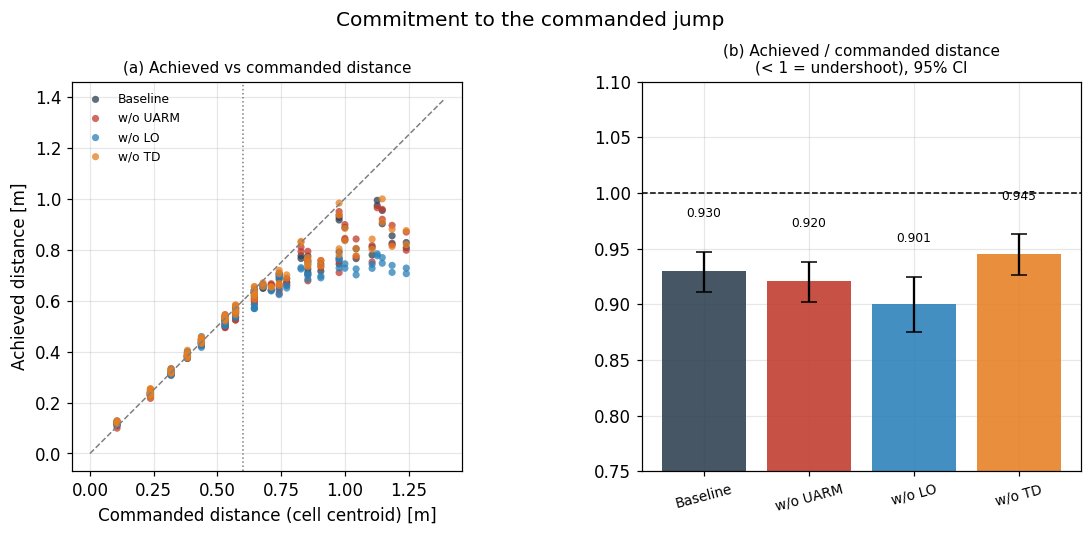

  w/o UARM: ratio 0.9205 vs baseline 0.9300 (-1.2%, p 0.03742 *), 114 failures vs 62
    w/o LO: ratio 0.9006 vs baseline 0.9300 (-3.2%, p 0.001553 **), 0 failures vs 62
    w/o TD: ratio 0.9449 vs baseline 0.9300 (+1.5%, p 6.68e-05 ***), 170 failures vs 62


In [24]:
fig = plt.figure(figsize=(12.5, 4.6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1], wspace=0.26)

# (a) achieved vs commanded distance, per cell
ax = fig.add_subplot(gs[0, 0])
for n, e in exps.items():
    ach = np.array([np.nanmean(e.actual_dist[(e.cell == c) & e.ok])
                    if ((e.cell == c) & e.ok).sum() >= 3 else np.nan
                    for c in range(part.n_cells)])
    ax.scatter(cdist[valid_cells], ach[valid_cells], s=22, color=e.color, alpha=0.75,
               edgecolors="none", label=e.label)
lim = np.nanmax(cdist[valid_cells]) * 1.12
ax.plot([0, lim], [0, lim], "--", color="grey", lw=1)
ax.axvline(D_KNEE, color="grey", ls=":", lw=1)
ax.set_xlabel("Commanded distance (cell centroid) [m]")
ax.set_ylabel("Achieved distance [m]")
ax.set_title("(a) Achieved vs commanded distance", fontsize=10)
ax.set_aspect("equal", "box")
ax.legend(fontsize=8)

# (b) ratio per cell
ax = fig.add_subplot(gs[0, 1])
bar_with_ci(ax, "dist_ratio", fmt="{:.3f}")
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_ylim(0.75, 1.10)
ax.set_title("(b) Achieved / commanded distance\n(< 1 = undershoot), 95% CI", fontsize=10)

fig.suptitle("Commitment to the commanded jump", y=1.02)
savefig(fig, "fig5_commitment")
plt.show()

for n in abl:
    print(f"{exps[n].label:>10}: ratio {strat('dist_ratio', n):.4f} vs baseline "
          f"{strat('dist_ratio', BASELINE):.4f} "
          f"({S(n, 'dist_ratio', 'rel'):+.1f}%, p {S(n, 'dist_ratio', 'p_holm'):.4g} "
          f"{S(n, 'dist_ratio', 'sig')}), "
          f"{int(exps[n].fail.sum())} failures vs {int(base.fail.sum())}")

## 9. Table and draft text

In [25]:
stats_df.to_csv(osp.join(FIG_DIR, "ablation_cell_stats.csv"), index=False)
tex = summary.to_latex(index=False, float_format="%.3f", escape=False)
with open(osp.join(FIG_DIR, "ablation_table.tex"), "w") as fh:
    fh.write(tex)
print(tex)

\begin{tabular}{lrrrrrrrr}
\toprule
Policy & Landing error [m] & Failure rate [%] & Achieved / commanded dist. [-] & Bounce distance [m] & Lift-off position [m] & Lift-off linear velocity [m/s] & Lift-off orientation [deg] & Lift-off angular velocity [rad/s] \\
\midrule
Baseline & 0.080 & 1.670 & 0.930 & 0.159 & 0.021 & 0.199 & 2.299 & 0.431 \\
w/o UARM & 0.089 & 2.850 & 0.920 & 0.158 & 0.017 & 0.281 & 2.150 & 0.467 \\
w/o LO & 0.102 & 0.000 & 0.901 & 0.142 & 0.026 & 0.500 & 3.076 & 1.381 \\
w/o TD & 0.088 & 4.350 & 0.945 & 0.168 & 0.021 & 0.239 & 2.717 & 0.581 \\
\bottomrule
\end{tabular}



In [26]:
def fp(p):
    return "< 0.001" if p < 1e-3 else f"= {p:.3f}"


def line(n, a):
    head = (f"{MNAME[a]} {strat(a, BASELINE):.3f} -> {strat(a, n):.3f} {MUNIT[a]} "
            f"({S(n, a, 'rel'):+.0f}%, 95% CI [{S(n, a, 'ci_lo'):+.3f}, {S(n, a, 'ci_hi'):+.3f}]")
    if S(n, a, "verdict") == "regional":
        return (head + f"; the mean difference excludes zero but only {S(n, a, 'worse'):.0f}% of "
                f"cells are worse, so the effect is concentrated in part of the workspace rather "
                f"than uniform)")
    return head + (f", p {fp(S(n, a, 'p_holm'))}, worse in {S(n, a, 'worse'):.0f}% of the "
                   f"workspace)")


def fail_line(n):
    r = FAIL_DF[FAIL_DF["Policy"] == exps[n].label].iloc[0]
    b = FAIL_DF[FAIL_DF["Policy"] == base.label].iloc[0]
    if r["failures"] == 0:
        return (f"no failures were recorded in {int(r['n'])} jumps (95% upper bound "
                f"{r['ci_hi']:.2f}%) against {int(b['failures'])} for the baseline "
                f"(Fisher exact p {fp(r['p_holm'])})")
    return (f"the failure rate rises from {b['rate']:.2f}% to {r['rate']:.2f}% "
            f"({int(b['failures'])} to {int(r['failures'])} of {int(r['n'])} jumps, "
            f"odds ratio {r['odds']:.2f}, Fisher exact p {fp(r['p_holm'])})")


L = ["# Section 5.6 — ablation study (auto-generated draft)", ""]
L.append(f"Each policy was evaluated on an independently sampled random target set "
         f"({', '.join(f'{e.label}: {e.n}' for e in exps.values())} jumps). Because the target sets "
         f"differ, policies are compared over a shared {GRID_NX}x{GRID_NY} partition of the command "
         f"space ({int(VALID.sum())} usable cells); reported values are stratified over cells, "
         f"confidence intervals are cluster bootstraps over cells, and p-values are Wilcoxon "
         f"signed-rank over cells with Holm correction. Landing error is censored at {PEN_CAP} m "
         f"for failed jumps so that a failure-prone policy cannot appear accurate through "
         f"survivorship.")
L.append("")

def knee_sentence(n):
    r = knee[knee["Ablation"] == exps[n].label]
    if r.empty:
        return ""
    r = r.iloc[0]
    if r["p_holm"] < 0.05 and r["far"] > r["near"]:
        return (f" The degradation is confined to long jumps: the per-cell gap is "
                f"{r['near']:+.3f} m for targets within {D_KNEE} m against {r['far']:+.3f} m "
                f"beyond it ({r['ratio']:.1f}x, Mann-Whitney over cells p "
                f"{fp(r['p_holm'])}), matching the threshold already reported in Section 5.3.1.")
    return (f" The gap does not differ significantly between targets within {D_KNEE} m "
            f"({r['near']:+.3f} m) and beyond it ({r['far']:+.3f} m, p {fp(r['p_holm'])}), "
            f"so the effect is spread over the whole workspace rather than confined to "
            f"long jumps.")


if "no_uarm" in exps:
    n = "no_uarm"
    L.append("**UARM extension.** " + line(n, "pos_err_pen") + ", and "
             + fail_line(n) + "." + knee_sentence(n))
    L.append(f"The mechanism is visible in the lift-off state: lift-off linear velocity error "
             f"rises by {S(n, 'lo_vel', 'rel'):+.0f}% while lift-off position error "
             f"{'falls' if S(n, 'lo_pos', 'rel') < 0 else 'rises'} by "
             f"{abs(S(n, 'lo_pos', 'rel')):.0f}%. Unable to charge for a high lift-off velocity "
             f"without violating the minimum-height constraint (Fig. 6), the policy retreats to a "
             f"lower-energy thrust that the low-level controller tracks more easily in position "
             f"but which does not reach the velocity the target requires.")
    L.append("")

n = "no_bounce_angular_touchdown"
if n in exps and exps[n].bounce is not None:
    acc_sig = S(n, "pos_err_pen", "p_holm") < 0.05
    L.append("**Touchdown penalties.** " + line(n, "bounce") + ", and " + fail_line(n) + ". "
             + ("Landing accuracy also degrades ("
                + line(n, "pos_err_pen") + ")."
                if acc_sig else
                f"Landing accuracy is not significantly affected "
                f"({strat('pos_err_pen', BASELINE):.3f} -> {strat('pos_err_pen', n):.3f} m, "
                f"p {fp(S(n, 'pos_err_pen', 'p_holm'))}, with the sign of the per-cell difference "
                f"essentially random across the workspace: worse in only "
                f"{S(n, 'pos_err_pen', 'worse'):.0f}% of cells). The effect of this term is "
                f"therefore on landing stability rather than on tracking accuracy.")
             + " Since no landing controller is used, the residual energy at touchdown cannot be "
               "dissipated, so these are precisely the landing conditions the penalty exists to "
               "avoid.")
    L.append("")

n = LO_MAP_POLICY
if n in exps:
    parts = [line(n, a) for a in lo_have]
    L.append("**Lift-off penalty.** Removing it degrades tracking of the commanded lift-off state: "
             + "; ".join(parts) + ". The achieved lift-off state therefore departs from the one the "
             "policy commanded, and since the ballistic relations of Section 5.2 are evaluated on "
             "the commanded state before the jump is executed, the physical interpretation of the "
             "action — the predicted apex and landing point — no longer describes the motion the "
             "robot performs.")
    rr = S(n, "dist_ratio", "rel")
    nf = int(exps[n].fail.sum())
    if nf < base.fail.sum():
        under = np.isfinite(rr) and rr < 0 and S(n, "dist_ratio", "p_holm") < 0.05
        L.append(f"For this policy {fail_line(n)}. " + (
                     f"It achieves this by under-committing rather than by landing more reliably: "
                     f"the achieved/commanded distance ratio drops from "
                     f"{strat('dist_ratio', BASELINE):.3f} to {strat('dist_ratio', n):.3f} "
                     f"({rr:+.1f}%, p {fp(S(n, 'dist_ratio', 'p_holm'))}), i.e. it systematically "
                     f"arrives short of distant targets instead of attempting them and falling. "
                     f"The result is a policy that is stable but inaccurate and, above all, no "
                     f"longer predictable from its commanded action."
                     if under else
                     f"The achieved/commanded distance ratio is "
                     f"{strat('dist_ratio', n):.3f} against {strat('dist_ratio', BASELINE):.3f} "
                     f"for the baseline ({rr:+.1f}%, p {fp(S(n, 'dist_ratio', 'p_holm'))}), so "
                     f"under-commitment does not by itself explain the absence of failures; this "
                     f"warrants a sentence in the paper rather than being left unaddressed."))
    L.append("")

cav = ["no landing controller is used, so the landing figures are a lower bound on achievable "
       "performance (cf. Section 5.3.1)"]
if INCLUDE_SEED_CAVEAT:
    cav.insert(0, "a single training seed per condition, so the p-values quantify variation across "
                  "the command space rather than across training runs")
L.append("*Caveats:* " + "; ".join(cav) + ".")

report = "\n".join(L)
with open(osp.join(FIG_DIR, "section_5_6_draft.md"), "w") as fh:
    fh.write(report)
print(report)
print()
print("outputs in:", FIG_DIR)
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)

# Section 5.6 — ablation study (auto-generated draft)

Each policy was evaluated on an independently sampled random target set (Baseline: 4096, w/o UARM: 4096, w/o LO: 4096, w/o TD: 4096 jumps). Because the target sets differ, policies are compared over a shared 12x8 partition of the command space (96 usable cells); reported values are stratified over cells, confidence intervals are cluster bootstraps over cells, and p-values are Wilcoxon signed-rank over cells with Holm correction. Landing error is censored at 0.5 m for failed jumps so that a failure-prone policy cannot appear accurate through survivorship.

**UARM extension.** Landing error 0.080 -> 0.089 m (+11%, 95% CI [+0.004, +0.014], p = 0.005, worse in 69% of the workspace), and the failure rate rises from 1.51% to 2.78% (62 to 114 of 4096 jumps, odds ratio 1.86, Fisher exact p < 0.001). The gap does not differ significantly between targets within 0.6 m (+0.005 m) and beyond it (+0.014 m, p = 1.000), so the effect is spread ove